# Eleven years of Polish power prices

**Cenergia — Notebook 01: market EDA**

This notebook explores the day-ahead electricity price series for Poland (PLN/MWh)
that backs the forecasting model built later in this project. It answers three
questions before any modeling happens: *what does the data actually contain, what
regimes has the market been through, and what daily/weekly/annual structure is
there for a forecaster to exploit?*

All statistics below are computed live from the warehouse — nothing here is a
hand-typed number.


## Setup

Imports and a small, consistent color palette used throughout the notebook —
one hue per recurring category (data source, season, weekday-type), plus a
dedicated red reserved for the negative-price story so it reads the same way
every time it appears.


In [1]:
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from cenergia import analysis
from cenergia.features.matrix import BREAK_TS_UTC

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

# Muted, colorblind-checked categorical palette (fixed hue order, reused as-is
# across every chart so a given category always gets the same color).
BLUE, AQUA, AMBER, GREEN, VIOLET, RED, MAGENTA, ORANGE = (
    "#2a78d6",
    "#1baf7a",
    "#eda100",
    "#008300",
    "#4a3aa7",
    "#d03b3b",
    "#e87ba4",
    "#eb6834",
)
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

sns.set_theme(
    style="white",
    rc={
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_SECONDARY,
        "text.color": INK,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "grid.color": GRID,
        "font.family": "sans-serif",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    },
)
FIGSIZE_WIDE = (11, 4.5)

## 1. The dataset

The hourly price series (`staging.price_hourly`) is stitched from two sources
that never overlap in time: **Ember**'s day-ahead Polish price series (EUR/MWh,
converted to PLN with NBP's daily EUR/PLN fixing) covers the long history, and
**PSE**'s CSDAC auction results (native PLN/MWh, aggregated from 15-minute to
hourly) take over once PSE's own feed starts. A separate cross-source QA table
compares the two on their one-day overlap; the switch itself doesn't lose or
duplicate a single hour.


In [2]:
df = analysis.price_hourly()

sources = (
    df.groupby("source")
    .agg(
        rows=("price_pln_mwh", "size"),
        first_ts_utc=("ts_utc", "min"),
        last_ts_utc=("ts_utc", "max"),
    )
    .assign(share_pct=lambda d: (d["rows"] / len(df) * 100).round(1))
    .sort_values("first_ts_utc")
)
sources

,rows,first_ts_utc,last_ts_utc,share_pct
source,,,,
ember,82822,2015-01-02 00:00:00,2024-06-13 21:00:00,82.0
pse,18192,2024-06-13 22:00:00,2026-07-11 21:00:00,18.0


Two sources, zero gaps at the seam: Ember runs from the start of 2015 up to the
morning PSE's own feed begins, and PSE picks up from exactly that hour onward.
Together they give a single continuous hourly series with no manual patching
required at the boundary.


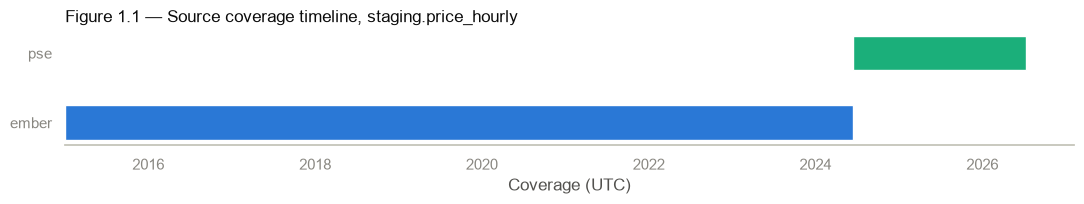

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.2))
colors = {"ember": BLUE, "pse": AQUA}
for _, row in sources.iterrows():
    ax.barh(
        row.name,
        (row["last_ts_utc"] - row["first_ts_utc"]).days,
        left=row["first_ts_utc"],
        color=colors[row.name],
        height=0.5,
    )
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Coverage (UTC)")
ax.set_title("Figure 1.1 — Source coverage timeline, staging.price_hourly", loc="left")
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [4]:
n_total = len(df)
n_years = df["ts_local"].dt.year.nunique()
print(
    f"{n_total:,} hourly rows spanning {n_years} calendar years "
    f"({df['ts_utc'].min():%Y-%m-%d} to {df['ts_utc'].max():%Y-%m-%d}, UTC)."
)

101,014 hourly rows spanning 12 calendar years (2015-01-02 to 2026-07-11, UTC).


That's the raw material for everything below: one uninterrupted hourly price
series, long enough to contain multiple market regimes.


## 2. Eleven years in one chart

Monthly mean price tells the regime story at a glance. Four things happened to
the Polish day-ahead market in this window: a calm pre-crisis period, a sharp
COVID-era demand dip, the 2021–2022 energy crisis, and — since 2023 — a
renewables-driven era with a widening negative-price problem. The dashed line
marks `BREAK_TS_UTC`, the moment PSE's market moved from hourly to 15-minute
settlement (2025-09-30 22:00 UTC); everything to its right is on the new
regime.


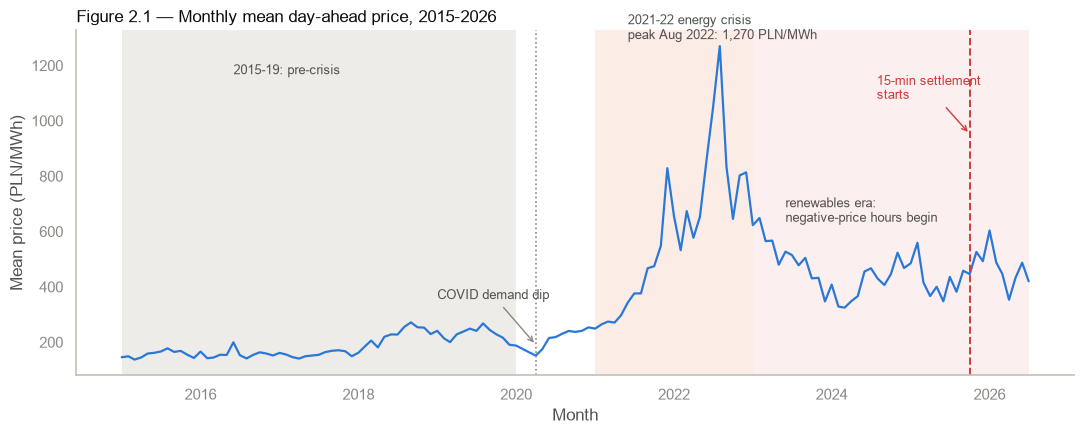

In [5]:
monthly = (
    df.assign(month=df["ts_local"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp())
    .groupby("month")["price_pln_mwh"]
    .mean()
)
peak_month = monthly.idxmax()
covid_low_month = monthly.loc["2020-01":"2020-12"].idxmin()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.plot(monthly.index, monthly.values, color=BLUE, lw=1.6)

ax.axvspan(pd.Timestamp("2015-01-01"), pd.Timestamp("2019-12-31"), color=GRID, alpha=0.6, lw=0)
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2022-12-31"), color=ORANGE, alpha=0.12, lw=0)
ax.axvspan(pd.Timestamp("2023-01-01"), monthly.index.max(), color=RED, alpha=0.08, lw=0)
ax.axvline(covid_low_month, color=INK_MUTED, ls=":", lw=1.2)
ax.axvline(BREAK_TS_UTC, color=RED, ls="--", lw=1.4)

ax.annotate(
    "2015-19: pre-crisis",
    xy=(pd.Timestamp("2016-06-01"), monthly.max() * 0.92),
    color=INK_SECONDARY,
    fontsize=9,
)
ax.annotate(
    "COVID demand dip",
    xy=(covid_low_month, monthly.max() * 0.15),
    xytext=(pd.Timestamp("2019-01-01"), monthly.max() * 0.28),
    arrowprops={"arrowstyle": "->", "color": INK_MUTED, "lw": 1},
    color=INK_SECONDARY,
    fontsize=9,
)
crisis_xy = (peak_month, monthly.max())
crisis_xytext = (pd.Timestamp("2021-06-01"), monthly.max() * 1.02)
ax.annotate(
    f"2021-22 energy crisis\npeak {peak_month:%b %Y}: {monthly.max():,.0f} PLN/MWh",
    xy=crisis_xy,
    xytext=crisis_xytext,
    color=INK_SECONDARY,
    fontsize=9,
)
renewables_xy = (pd.Timestamp("2023-06-01"), monthly.max() * 0.5)
ax.annotate(
    "renewables era:\nnegative-price hours begin", xy=renewables_xy, color=INK_SECONDARY, fontsize=9
)
ax.annotate(
    "15-min settlement\nstarts",
    xy=(BREAK_TS_UTC, monthly.max() * 0.75),
    xytext=(BREAK_TS_UTC - pd.Timedelta(days=430), monthly.max() * 0.85),
    arrowprops={"arrowstyle": "->", "color": RED, "lw": 1},
    color=RED,
    fontsize=9,
)

ax.set_ylabel("Mean price (PLN/MWh)")
ax.set_xlabel("Month")
ax.set_title("Figure 2.1 — Monthly mean day-ahead price, 2015-2026", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
yearly = analysis.yearly_stats()
baseline_years = yearly["year"].between(2015, 2017)
baseline_mean = yearly.loc[baseline_years, "mean"].mean()
baseline_std = yearly.loc[baseline_years, "std"].mean()
year_2019_mean = monthly.loc["2019-01":"2019-12"].mean()
y2022 = yearly.loc[yearly["year"] == 2022].iloc[0]

print(f"2015-2017 baseline: {baseline_mean:,.0f} PLN/MWh mean, std {baseline_std:,.0f}.")
print(
    f"COVID low: {covid_low_month:%B %Y} averaged {monthly[covid_low_month]:,.0f} PLN/MWh, "
    f"below the {year_2019_mean:,.0f} PLN/MWh 2019 average."
)
print(
    f"Crisis peak: {peak_month:%B %Y} averaged {monthly.max():,.0f} PLN/MWh "
    f"({monthly.max() / baseline_mean:.1f}x the 2015-17 baseline)."
)
print(
    f"2022 full-year mean: {y2022['mean']:,.0f} PLN/MWh, std {y2022['std']:,.0f} "
    "- the most volatile year on record."
)

2015-2017 baseline: 156 PLN/MWh mean, std 54.
COVID low: April 2020 averaged 151 PLN/MWh, below the 230 PLN/MWh 2019 average.
Crisis peak: August 2022 averaged 1,270 PLN/MWh (8.1x the 2015-17 baseline).
2022 full-year mean: 783 PLN/MWh, std 378 - the most volatile year on record.


The chart makes the point better than a table could: 2015–2019 sits in a
comparatively calm band, 2020 dips below the pre-COVID trend as demand
collapsed, 2021–2022 is a violent step-change driven by the European gas
crisis (August 2022 is the single worst month in the series), and everything
from 2023 onward runs at a higher and far more volatile level — the price
floor now regularly goes negative, which Section 4 quantifies.


## 3. Seasonality at three scales

Three views of the same seasonal structure, each at a different time scale:
the shape of an average day by season, the shape of an average week, and how
much a whole year's worth of hourly prices vary month to month.


### 3.1 Average day shape by season

`marts.typical_shape` already holds mean price by (season, year, hour). We
average across all eleven years per season below, which is enough to see the
structural difference between seasons: winter and autumn still show a classic
overnight-low / late-afternoon-peak thermal-generation shape, while spring and
summer already dip to their daily minimum around midday — the solar effect —
even blended across years with very different solar buildouts.


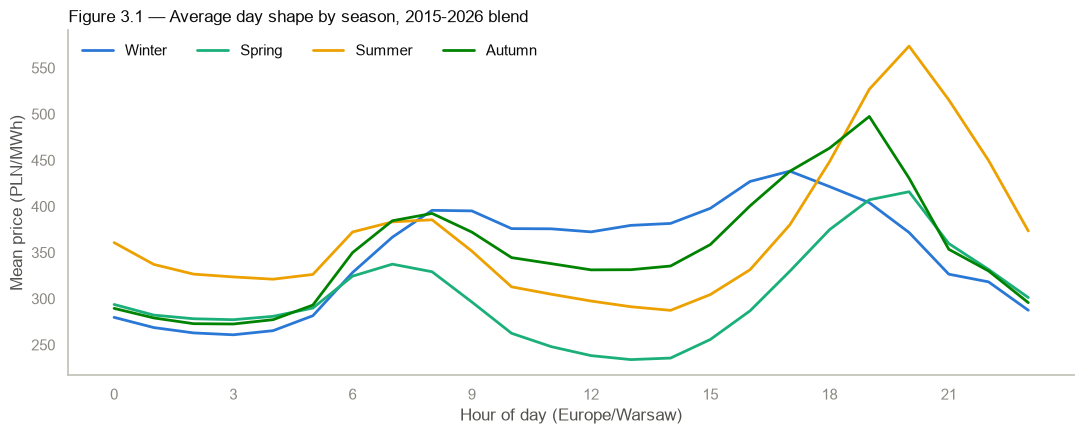

In [7]:
shape = analysis.load_table("marts.typical_shape")
day_shape = shape.groupby(["season", "hour_local"])["avg_price"].mean().reset_index()

season_colors = {"winter": BLUE, "spring": AQUA, "summer": AMBER, "autumn": GREEN}
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
for season in ["winter", "spring", "summer", "autumn"]:
    sub = day_shape[day_shape["season"] == season].sort_values("hour_local")
    ax.plot(
        sub["hour_local"],
        sub["avg_price"],
        color=season_colors[season],
        lw=2,
        label=season.capitalize(),
    )
ax.set_xlabel("Hour of day (Europe/Warsaw)")
ax.set_ylabel("Mean price (PLN/MWh)")
ax.set_xticks(range(0, 24, 3))
ax.set_title("Figure 3.1 — Average day shape by season, 2015-2026 blend", loc="left")
ax.legend(frameon=False, ncol=4, loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
for season in ["winter", "spring", "summer", "autumn"]:
    sub = day_shape[day_shape["season"] == season].sort_values("hour_local")
    trough_h = int(sub.loc[sub["avg_price"].idxmin(), "hour_local"])
    peak_h = int(sub.loc[sub["avg_price"].idxmax(), "hour_local"])
    print(f"{season:7s}: trough at {trough_h:02d}:00, peak at {peak_h:02d}:00")

winter : trough at 03:00, peak at 17:00
spring : trough at 13:00, peak at 20:00
summer : trough at 14:00, peak at 20:00
autumn : trough at 03:00, peak at 19:00


### 3.2 Weekly pattern

Averaging by day of week over the full history, weekdays trade close together
and both weekend days trade meaningfully lower — demand from industry and
commerce falls away on Saturday and Sunday while generation doesn't.


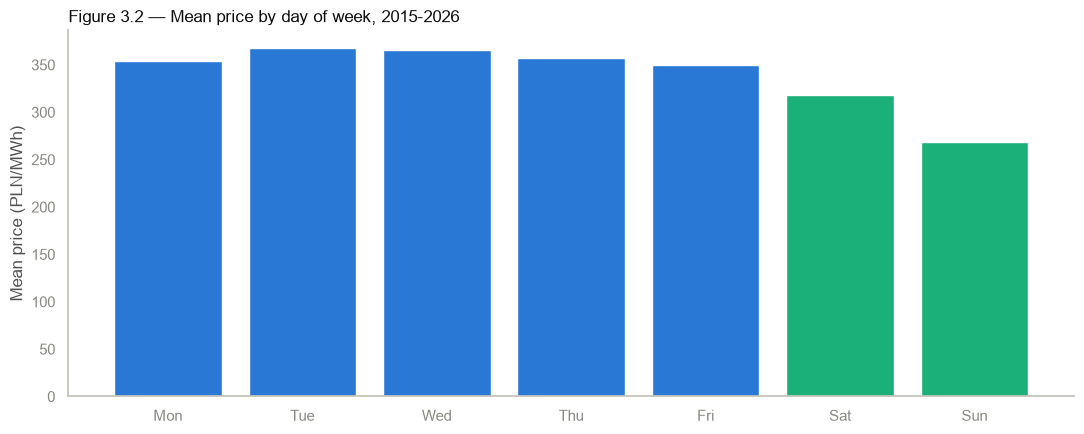

In [9]:
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_mean = df.groupby(df["ts_local"].dt.dayofweek)["price_pln_mwh"].mean()
is_weekend = [i >= 5 for i in dow_mean.index]

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
ax.bar(
    [dow_names[i] for i in dow_mean.index],
    dow_mean.values,
    color=[AQUA if w else BLUE for w in is_weekend],
)
ax.set_ylabel("Mean price (PLN/MWh)")
ax.set_title("Figure 3.2 — Mean price by day of week, 2015-2026", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

In [10]:
weekday_mean = dow_mean.loc[0:4].mean()
weekend_mean = dow_mean.loc[5:6].mean()
print(
    f"Weekday mean {weekday_mean:,.0f} PLN/MWh vs weekend mean {weekend_mean:,.0f} PLN/MWh "
    f"({(1 - weekend_mean / weekday_mean) * 100:.0f}% lower on weekends)."
)

Weekday mean 359 PLN/MWh vs weekend mean 293 PLN/MWh (18% lower on weekends).


### 3.3 Annual cycle

Monthly boxplots of the hourly series (all years pooled) show winter months
carrying both a higher median and a longer upper tail — cold-weather demand
spikes are what push prices highest — while summer months, despite a lower
median, have started to show a heavier lower tail as negative midday prices
become common.


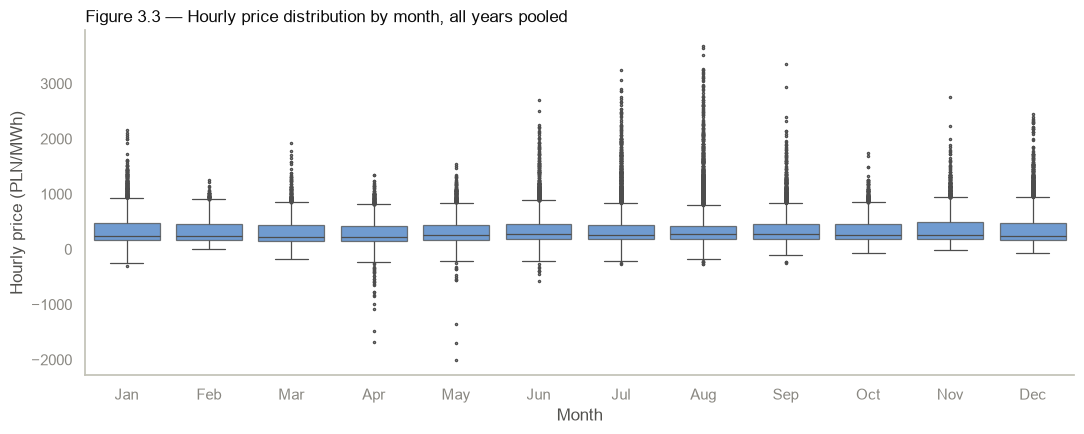

In [11]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_plot_df = df.assign(month_name=df["ts_local"].dt.month.map(lambda m: month_labels[m - 1]))

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
sns.boxplot(
    data=month_plot_df,
    x="month_name",
    y="price_pln_mwh",
    order=month_labels,
    ax=ax,
    color=BLUE,
    fliersize=1.5,
    linewidth=0.9,
    boxprops={"alpha": 0.75},
    showfliers=True,
)
ax.set_xlabel("Month")
ax.set_ylabel("Hourly price (PLN/MWh)")
ax.set_title("Figure 3.3 — Hourly price distribution by month, all years pooled", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## 4. Distributions & the negative-price era

`yearly_stats()` turns the hourly series into one row per year: mean, std,
min, max, and — the number that matters most for a renewables-heavy grid —
how many hours settled below zero.


In [12]:
yearly

,year,mean,std,min,max,negative_hours
0,2015,155.9,45.9,69.6,"1,392.7",0
1,2016,156.7,62.8,69.9,"1,215.7",0
2,2017,156.5,51.8,69.6,"1,036.2",0
3,2018,222.7,70.4,70.7,889.2,0
4,2019,229.8,49.2,5.0,490.2,0
5,2020,207.4,55.2,49.7,663.8,0
6,2021,398.5,218.5,56.0,"2,447.2",0
7,2022,782.7,377.8,75.7,"3,678.1",0
8,2023,508.6,175.3,-59.8,"1,027.0",43
9,2024,414.5,213.4,-265.1,"2,748.1",197


In [13]:
neg = df.loc[df["price_pln_mwh"] < 0].sort_values("ts_local")
first_negative = neg.iloc[0]
total_negative = len(neg)
print(
    f"First negative-price hour: {first_negative['ts_local']:%Y-%m-%d %H:%M} local "
    f"({first_negative['price_pln_mwh']:,.1f} PLN/MWh)."
)
print(
    f"Negative-price hours to date: {total_negative:,} "
    f"({total_negative / len(df) * 100:.2f}% of all hours in the series)."
)

First negative-price hour: 2023-06-11 11:00 local (-5.7 PLN/MWh).
Negative-price hours to date: 798 (0.79% of all hours in the series).


Negative prices don't appear at all until mid-2023, then grow every year
since — the fingerprint of solar capacity outpacing flexible demand and
storage on sunny midday hours. That trend shows up even more clearly as a
widening **duck-curve spread**: the gap between the midday trough (11:00-14:00
local, when solar output peaks) and the evening peak (18:00-20:00 local, when
solar has faded but demand hasn't).


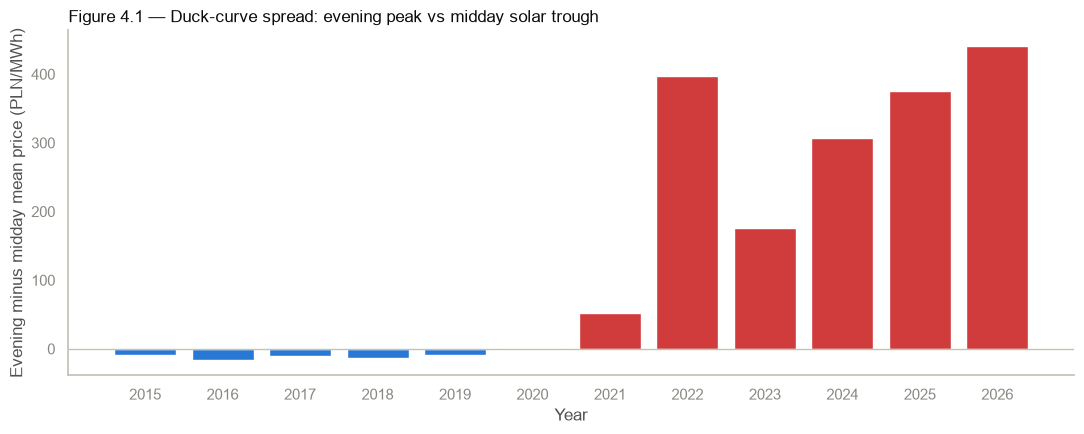

In [14]:
hour_local = df["ts_local"].dt.hour
year_local = df["ts_local"].dt.year
is_midday = hour_local.between(11, 14)
is_evening = hour_local.between(18, 20)
midday = df.loc[is_midday].groupby(year_local[is_midday])["price_pln_mwh"].mean()
evening = df.loc[is_evening].groupby(year_local[is_evening])["price_pln_mwh"].mean()
spread = (evening - midday).dropna()

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
colors = [RED if v > 0 else BLUE for v in spread.values]
ax.bar(spread.index.astype(str), spread.values, color=colors)
ax.axhline(0, color=BASELINE, lw=1)
ax.set_ylabel("Evening minus midday mean price (PLN/MWh)")
ax.set_xlabel("Year")
ax.set_title("Figure 4.1 — Duck-curve spread: evening peak vs midday solar trough", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

In [15]:
print(f"2015 spread: {spread.loc[2015]:,.0f} PLN/MWh (evening was cheaper than midday).")
print(
    f"2025 spread: {spread.loc[2025]:,.0f} PLN/MWh - "
    f"evening now trades {spread.loc[2025] - spread.loc[2015]:,.0f} PLN/MWh richer than midday, "
    f"relative to 2015."
)

2015 spread: -9 PLN/MWh (evening was cheaper than midday).
2025 spread: 376 PLN/MWh - evening now trades 385 PLN/MWh richer than midday, relative to 2015.


In 2015 the spread was slightly negative — evening was, if anything, a touch
*cheaper* than midday. By 2025 evening trades several hundred PLN/MWh above
midday: the duck curve has gone from flat to pronounced within a decade, and
it deepens every year in this data.


## 5. Autocorrelation

The forecasting model (later notebooks) uses lagged prices as features. Before
picking which lags, it helps to see where the series actually correlates with
its own past. We use the PSE-era hourly series (native hourly cadence,
2024-06 onward, no unit-conversion or FX noise) and look at both the raw
autocorrelation (ACF) and the partial autocorrelation (PACF), which strips out
the effect of the lags in between.


In [16]:
pse_series = (
    df.loc[df["source"] == "pse"].sort_values("ts_utc").set_index("ts_utc")["price_pln_mwh"]
)
pse_series.index = pse_series.index.astype("datetime64[ns]")
pse_series = pse_series.asfreq("h")
n_gaps = int(pse_series.isna().sum())
print(
    f"PSE-era hourly series: {len(pse_series):,} hours, {n_gaps} gap(s) "
    "after reindexing to an exact hourly grid."
)

PSE-era hourly series: 18,192 hours, 0 gap(s) after reindexing to an exact hourly grid.


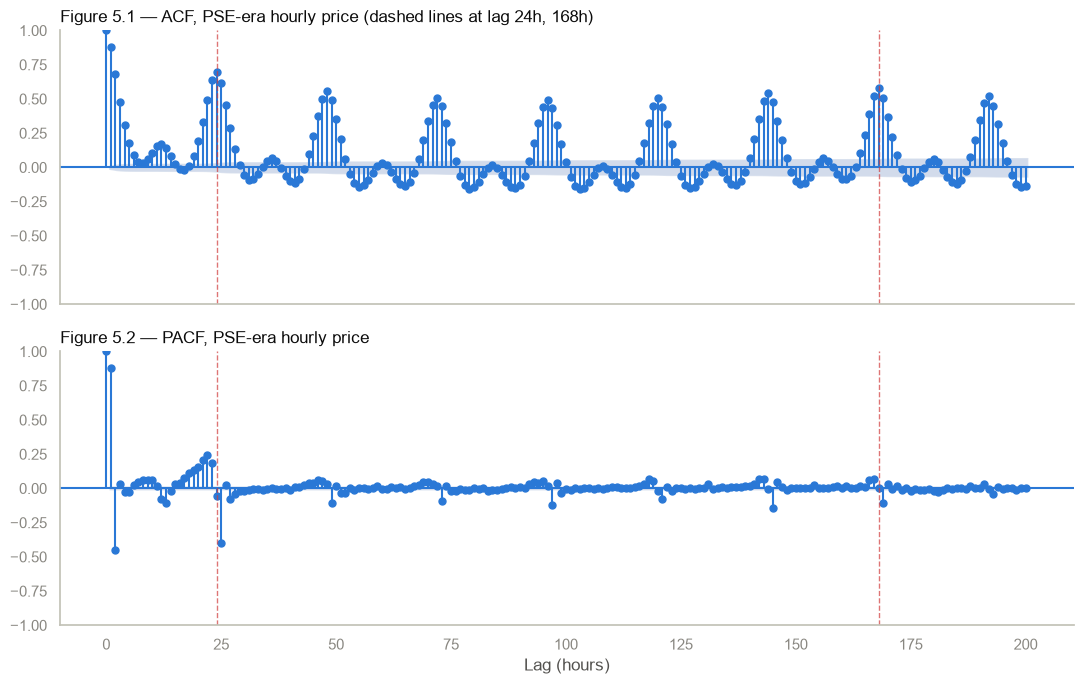

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
acf_kwargs = {"color": BLUE, "vlines_kwargs": {"colors": BLUE}, "title": ""}
plot_acf(pse_series.dropna(), lags=200, ax=axes[0], **acf_kwargs)
plot_pacf(pse_series.dropna(), lags=200, ax=axes[1], method="ywm", **acf_kwargs)
for ax in axes:
    for lag in (24, 168):
        ax.axvline(lag, color=RED, ls="--", lw=1, alpha=0.7)
acf_title = "Figure 5.1 — ACF, PSE-era hourly price (dashed lines at lag 24h, 168h)"
axes[0].set_title(acf_title, loc="left")
axes[1].set_title("Figure 5.2 — PACF, PSE-era hourly price", loc="left")
axes[1].set_xlabel("Lag (hours)")
sns.despine()
plt.tight_layout()
plt.show()

In [18]:
from statsmodels.tsa.stattools import acf

acf_values = acf(pse_series.dropna(), nlags=200, fft=True)
print(f"ACF at lag 24h (same hour, previous day): {acf_values[24]:.2f}")
print(f"ACF at lag 168h (same hour, previous week): {acf_values[168]:.2f}")

ACF at lag 24h (same hour, previous day): 0.70
ACF at lag 168h (same hour, previous week): 0.58


Both the 24-hour and 168-hour lags stand out clearly against their
neighbours — the price at a given hour is strongly related to the price at
the same hour yesterday, and almost as strongly to the same hour last week.
That's exactly the daily-and-weekly seasonality the day-shape and weekday
charts above already showed visually, and it's the direct justification for
the `price_lag24` / `price_lag48` / `price_lag168` and 7-day rolling features
already built into the model's feature matrix (`src/cenergia/features/matrix.py`).


## 6. Takeaways

Five findings, each backed by a number computed above.


In [19]:
crisis_mult = monthly.max() / baseline_mean
neg_2024 = int(yearly.loc[yearly["year"] == 2024, "negative_hours"].item())
neg_2025 = int(yearly.loc[yearly["year"] == 2025, "negative_hours"].item())
spread_growth = spread.loc[2025] - spread.loc[2015]
weekend_discount = (1 - weekend_mean / weekday_mean) * 100
acf24, acf168 = acf_values[24], acf_values[168]

finding_1 = (
    f"1. The 2021-22 energy crisis pushed the single worst month ({peak_month:%B %Y}) "
    f"to {monthly.max():,.0f} PLN/MWh - {crisis_mult:.1f}x the calm 2015-17 baseline "
    f"of {baseline_mean:,.0f} PLN/MWh."
)
finding_2 = (
    f"2. Negative prices did not exist before {first_negative['ts_local']:%Y-%m-%d}; "
    f"by 2024-2025 they had reached {neg_2024:,} and {neg_2025:,} hours a year respectively."
)
finding_3 = (
    f"3. The midday-vs-evening duck-curve spread widened from {spread.loc[2015]:,.0f} "
    f"PLN/MWh in 2015 to {spread.loc[2025]:,.0f} PLN/MWh in 2025, "
    f"a swing of {spread_growth:,.0f} PLN/MWh."
)
finding_4 = (
    f"4. Prices carry strong daily and weekly memory: ACF at lag 24h is {acf24:.2f} "
    f"and at lag 168h is {acf168:.2f}, and weekends trade {weekend_discount:.0f}% "
    "below weekday prices on average."
)
finding_5 = (
    f"5. The series is continuous end to end: {n_total:,} hourly rows from two stitched "
    f"sources with a clean handover, and {n_gaps} gap(s) in the {len(pse_series):,}-hour "
    "PSE-era grid used for the autocorrelation analysis above."
)
print(finding_1)
print(finding_2)
print(finding_3)
print(finding_4)
print(finding_5)

1. The 2021-22 energy crisis pushed the single worst month (August 2022) to 1,270 PLN/MWh - 8.1x the calm 2015-17 baseline of 156 PLN/MWh.
2. Negative prices did not exist before 2023-06-11; by 2024-2025 they had reached 197 and 310 hours a year respectively.
3. The midday-vs-evening duck-curve spread widened from -9 PLN/MWh in 2015 to 376 PLN/MWh in 2025, a swing of 385 PLN/MWh.
4. Prices carry strong daily and weekly memory: ACF at lag 24h is 0.70 and at lag 168h is 0.58, and weekends trade 18% below weekday prices on average.
5. The series is continuous end to end: 101,014 hourly rows from two stitched sources with a clean handover, and 0 gap(s) in the 18,192-hour PSE-era grid used for the autocorrelation analysis above.
